# Week 6 Phase 2.5 — stable-depth model closure

This notebook closes one specific gap from Phase 2: Method B
(learned common effective nugget) and Method C
(observation-specific heteroskedastic alpha) are compared on
exactly the same 230 stable-window penetration-depth
simulations. Width, length, Method A, new kernels, Phase 3,
feature effects, active learning, and level-set estimation are
outside this notebook.

## 1. Why Phase 2.5 is needed

Phase 2 found a depth trade-off, but only C received a stable-only
refit. We first locate the repository and load the closure summary so
the exact unresolved question is explicit.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

START = Path.cwd().resolve()
ROOT = next(
    (
        candidate
        for candidate in (START, *START.parents)
        if (
            candidate
            / "outputs"
            / "week6_02_5_depth_model_closure"
        ).is_dir()
    ),
    None,
)
if ROOT is None:
    raise FileNotFoundError("Could not locate the repository root.")

OUT = ROOT / "outputs" / "week6_02_5_depth_model_closure"
P2 = ROOT / "outputs" / "week6_02_gp_response_noise_comparison"
summary = json.loads((OUT / "summary.json").read_text(encoding="utf-8"))
pd.Series(
    {
        "phase": summary["phase"],
        "stable simulations": summary["stable_subset_size"],
        "new predictions": summary["new_prediction_count"],
        "methods": summary["methods"],
        "decision": summary["decision"]["headline"],
    }
)

phase                                                  Week 6 Phase 2.5
stable simulations                                                  230
new predictions                                                     460
methods                           [B_learned_nugget, C_heteroskedastic]
decision              B is preferred for stable-window penetration d...
dtype: object

**For Burak.** Phase 2.5 is not a new model search. It supplies the missing matched
B-versus-C experiment. Nothing here can tell us which input causes
penetration depth or whether another kernel family would be better.

## 2. Load and validate Phase 2 artifacts

The immutable Phase 1 revision, ledger hash, Phase 2 configuration,
uncertainty artifact, and historical prediction hashes must match
before any Phase 2.5 result is interpreted.

In [2]:
config = json.loads(
    (OUT / "phase2_5_configuration.json").read_text(encoding="utf-8")
)
stable_input = pd.read_csv(OUT / "stable_depth_input_table.csv")
source_rows = pd.DataFrame(
    [
        ("Phase 1 revision", config["phase1_revision"]),
        ("Phase 1 ledger SHA-256", config["phase1_ledger_sha256"]),
        (
            "Phase 2 configuration SHA-256",
            config["phase2_configuration_sha256"],
        ),
        (
            "Phase 2 uncertainty SHA-256",
            config["phase2_uncertainty_sha256"],
        ),
        ("Protocol fingerprint", config["protocol_fingerprint"]),
    ],
    columns=["source", "recorded value"],
)
source_rows

,source,recorded value
0,Phase 1 revision,0e859b748fdbc8454f66e58e101e333ac0479d42
1,Phase 1 ledger SHA-256,10DEF11AB64D62444AC14FED506266BEB748EEB5BF892A...
2,Phase 2 configuration SHA-256,CBBA81F86E9B2B9FF46838B793733D9C7DE2982D1A398A...
3,Phase 2 uncertainty SHA-256,2CE2F5D7984D4A8483166434DD5A0FD7C6DFD700718ED9...
4,Protocol fingerprint,22C91E1C60AD977D52565416E744CCFD885D1AB6306512...


**For Burak.** A fingerprint is a file-content identifier. Matching fingerprints mean
this closure used the same validated source artifacts; they do not by
themselves prove that the scientific model is correct.

## 3. Construct the exact 230-simulation stable subset

The Phase 1 flag is checked against the expected 11 IDs. The remaining
230 IDs are unique and ordered by numeric simulation ID.

In [3]:
expected_removed = config["stable_subset"]["removed_simulation_ids"]
assert len(stable_input) == 230
assert stable_input["simulation_id"].is_unique
assert not stable_input["flag_primary_window_unstable"].astype(bool).any()
assert stable_input["fold_index"].tolist() == list(range(230))
pd.DataFrame(
    {
        "stable rows": [len(stable_input)],
        "removed rows": [len(expected_removed)],
        "first stable ID": [stable_input.iloc[0]["simulation_id"]],
        "last stable ID": [stable_input.iloc[-1]["simulation_id"]],
        "removed IDs": [", ".join(expected_removed)],
    }
)

,stable rows,removed rows,first stable ID,last stable ID,removed IDs
0,230,11,sim_00001,sim_00242,"sim_00002, sim_00006, sim_00018, sim_00029, si..."


**For Burak.** “Stable” means that Phase 1 did not raise its selected-window
instability flag. It does not mean the simulation is perfect or that
the removed simulations are invalid.

## 4. Restate B and C mathematically and in plain language

Both methods share the fixed isotropic Matérn 3/2 covariance. Only the
observation treatment changes.

In [4]:
model_rows = []
for method, settings in config["methods"].items():
    model_rows.append(
        {
            "method": method,
            "kernel": settings["kernel"],
            "evaluation variance": settings["evaluation_variance"],
            "interpretation": settings["interpretation"],
        }
    )
pd.DataFrame(model_rows)

,method,kernel,evaluation variance,interpretation
0,B_learned_nugget,"base kernel + WhiteKernel(0.01, (1e-8, 1e1))",total variance including optimized WhiteKernel...,learned common effective discrepancy; not stoc...
1,C_heteroskedastic,base kernel without WhiteKernel,oracle retrospective latent variance plus held...,observation-specific target-summary uncertaint...


**For Burak.** A nugget is a common residual variance learned by B. In scikit-learn it
is represented by `WhiteKernel`; here it is effective model discrepancy,
not random simulator noise. Heteroskedastic alpha means C gives
different training variances to different simulations. For example,
if a window variance is 0.04 µm² and the training-target standard
deviation is 20 µm, its normalized contribution is
0.04 / 20² = 0.0001 before the numerical floor.

## 5. Verify the identical cross-validation protocol

Leave-One-Out cross-validation (LOO) holds out one simulation, trains
on the other 229, and repeats this for every stable simulation.

In [5]:
pred_b = pd.read_csv(OUT / "stable_depth_B_loo_predictions.csv")
pred_c = pd.read_csv(OUT / "stable_depth_C_loo_predictions.csv")
protocol_check = pd.Series(
    {
        "B rows": len(pred_b),
        "C rows": len(pred_c),
        "same simulation order": (
            pred_b["simulation_id"].tolist()
            == pred_c["simulation_id"].tolist()
        ),
        "same fold indices": (
            pred_b["fold_index"].tolist()
            == pred_c["fold_index"].tolist()
        ),
        "same fold seeds": (
            pred_b["fold_random_seed"].tolist()
            == pred_c["fold_random_seed"].tolist()
        ),
        "training rows per fold": pred_b["training_size"].unique().tolist(),
        "features": pred_b["feature_columns"].unique().tolist(),
    }
)
assert protocol_check["same simulation order"]
assert protocol_check["same fold indices"]
assert protocol_check["same fold seeds"]
protocol_check

B rows                                       230
C rows                                       230
same simulation order                       True
same fold indices                           True
same fold seeds                             True
training rows per fold                     [229]
features                  [["P","VX","LS","ST"]]
dtype: object

**For Burak.** This alignment makes the comparison paired: B and C face exactly the
same held-out cases. Fold-local scaling means the held-out target never
influences scaling or hyperparameter optimization.

## 6. Run or load the exact 230-fold results

The reusable source performed 230 new B fits and 230 new C fits. This
notebook loads those audited rows rather than hiding another expensive
experiment inside one large cell.

In [6]:
required_prediction_columns = [
    "simulation_id",
    "observed_target_um",
    "predicted_mean_um",
    "latent_predictive_std_um",
    "evaluation_nlpd",
    "optimized_kernel",
    "runtime_seconds",
    "warnings",
    "any_hyperparameter_bound_hit",
]
assert pred_b[required_prediction_columns].shape == (230, 9)
assert pred_c[required_prediction_columns].shape == (230, 9)
pd.concat(
    [
        pred_b[required_prediction_columns].head(2).assign(method="B"),
        pred_c[required_prediction_columns].head(2).assign(method="C"),
    ],
    ignore_index=True,
)

,simulation_id,observed_target_um,predicted_mean_um,latent_predictive_std_um,evaluation_nlpd,optimized_kernel,runtime_seconds,warnings,any_hyperparameter_bound_hit,method
0,sim_00001,50.710190,52.363664,1.287478,1.987551,"2.45**2 * Matern(length_scale=6.63, nu=1.5) + ...",4.122530,NaN,False,B
1,sim_00003,34.838855,31.646153,1.921711,2.628025,"2.39**2 * Matern(length_scale=6.47, nu=1.5) + ...",3.475595,NaN,False,B
2,sim_00001,50.710190,52.090608,0.847715,2.079494,"1.12**2 * Matern(length_scale=2.39, nu=1.5)",3.446812,NaN,False,C
3,sim_00003,34.838855,30.251113,3.236612,3.098050,"1.11**2 * Matern(length_scale=2.35, nu=1.5)",4.323554,NaN,False,C


**For Burak.** Every row is one genuinely held-out stable simulation. The outputs
retain predictions, uncertainty, optimized kernels, warnings, and bound
hits so favorable aggregate metrics cannot conceal unstable fits.

## 7. Compare point-prediction metrics

MAE summarizes typical absolute error, RMSE penalizes large errors more,
R² compares against a constant-mean predictor, and nRMSE scales RMSE by
the observed depth range.

In [7]:
metrics = pd.read_csv(OUT / "stable_depth_model_metrics.csv")
point_columns = [
    "method",
    "mae_um",
    "median_absolute_error_um",
    "rmse_um",
    "r2",
    "nrmse",
]
metrics[point_columns].round(6)

,method,mae_um,median_absolute_error_um,rmse_um,r2,nrmse
0,B_learned_nugget,1.802271,1.339809,2.728943,0.968873,0.036104
1,C_heteroskedastic,2.076667,1.551698,3.013798,0.962036,0.039872


**For Burak.** Lower MAE/RMSE/nRMSE is better. R² is reported but is not the sole
decision rule. A result on these 230 simulations does not guarantee the
same ranking outside this design.

## 8. Compare uncertainty metrics

Calibration asks whether nominal intervals contain observations at
approximately their stated frequency. NLPD (negative log predictive
density) rewards accurate means and appropriately scaled uncertainty;
lower is better.

,method,mean_nlpd,median_nlpd,latent_95_coverage,observation_95_coverage,mean_latent_interval_width_um,mean_observation_interval_width_um,nlpd_variance_definition
0,B_learned_nugget,2.440425,2.034243,0.878261,0.952174,7.536475,10.342028,total predictive variance including learned Wh...
1,C_heteroskedastic,2.703817,2.243317,0.913043,0.913043,11.187058,11.215180,oracle retrospective latent variance plus held...


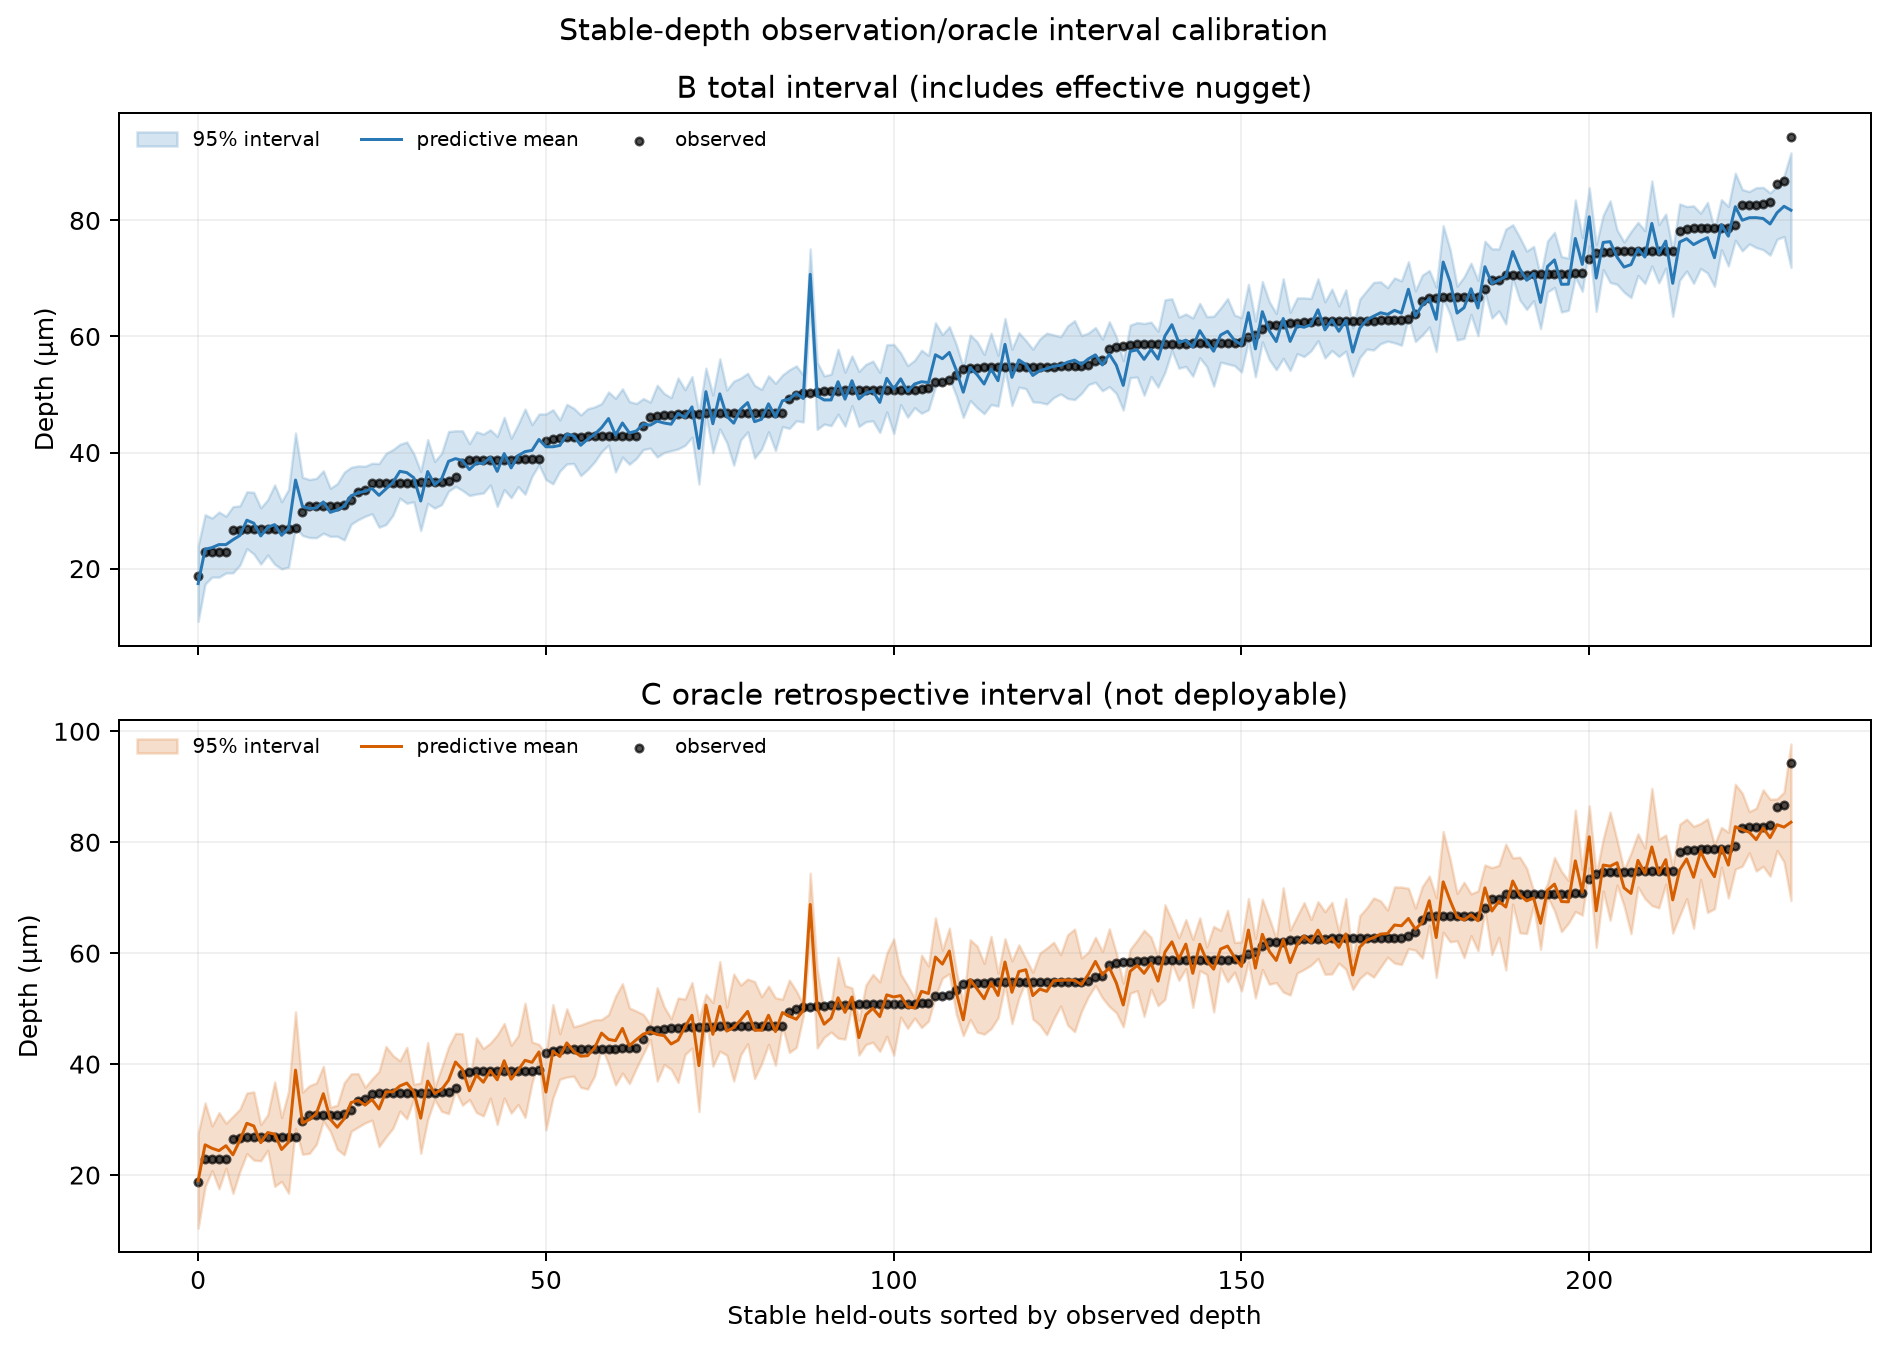

In [8]:
uncertainty_columns = [
    "method",
    "mean_nlpd",
    "median_nlpd",
    "latent_95_coverage",
    "observation_95_coverage",
    "mean_latent_interval_width_um",
    "mean_observation_interval_width_um",
    "nlpd_variance_definition",
]
display(metrics[uncertainty_columns].round(6))
display(
    Image(
        filename=str(
            OUT / "stable_depth_predictive_interval_calibration.png"
        )
    )
)

**For Burak.** Latent uncertainty concerns the smooth GP response before an observation
term is added. B total uncertainty includes its learned nugget. C's
oracle interval adds the held-out simulation's known-after-the-fact
bootstrap variance; “oracle” means retrospective, so it is not
deployable for a genuinely unseen simulation. Coverage should be close
to 95%, not maximized.

## 9. Perform the paired bootstrap comparison

A paired bootstrap jointly resamples the same simulation IDs for both
methods. A 95% confidence interval describes the resampling uncertainty
of the observed method difference.

,0
target,depth
method_B,B_learned_nugget
method_C,C_heteroskedastic
n_aligned_simulations,230
B_improved_count,134
C_improved_count,96
tie_count,0
observed_MAE_C_minus_B_um,0.274396
MAE_C_minus_B_ci95_low_um,0.134941
MAE_C_minus_B_ci95_high_um,0.422091


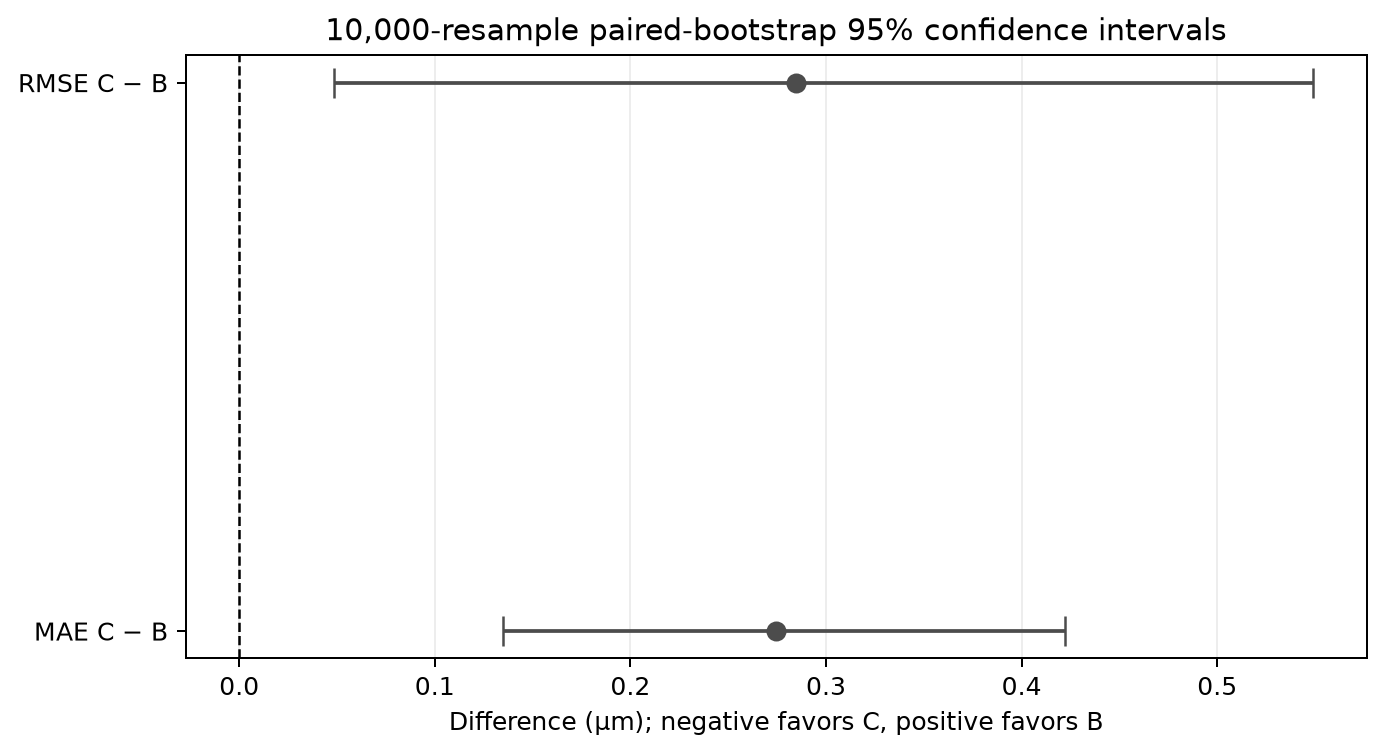

In [9]:
paired = pd.read_csv(OUT / "stable_depth_paired_comparison.csv")
paired_summary = pd.read_csv(
    OUT / "stable_depth_paired_bootstrap_summary.csv"
)
display(paired_summary.T)
display(
    Image(
        filename=str(
            OUT / "stable_depth_paired_bootstrap_intervals.png"
        )
    )
)

**For Burak.** Differences are C minus B: negative favors C and positive favors B. If
an interval crosses zero, superiority is not robust. An interval that
excludes zero supports a stable ranking for this matched dataset, not a
universal theorem about all possible simulations.

## 10. Compare stable refits with full-population-trained models

The same 230 stable held-outs are evaluated twice: once using models
trained with all other 240 simulations, and once using only the other
229 stable simulations.

,method,metric,full_population_model_stable_heldouts,stable_only_refit,percent_change,rmse_change_is_material
0,B_learned_nugget,mae_um,1.997767,1.802271,-9.785724,NaN
1,B_learned_nugget,rmse_um,3.382290,2.728943,-19.316721,True
2,B_learned_nugget,r2,0.952184,0.968873,1.752670,NaN
3,B_learned_nugget,mean_nlpd,2.725825,2.440425,-10.470221,NaN
10,C_heteroskedastic,mae_um,2.267474,2.076667,-8.414974,NaN
11,C_heteroskedastic,rmse_um,3.517802,3.013798,-14.327243,True
12,C_heteroskedastic,r2,0.948276,0.962036,1.450998,NaN
13,C_heteroskedastic,mean_nlpd,2.806032,2.703817,-3.642686,NaN


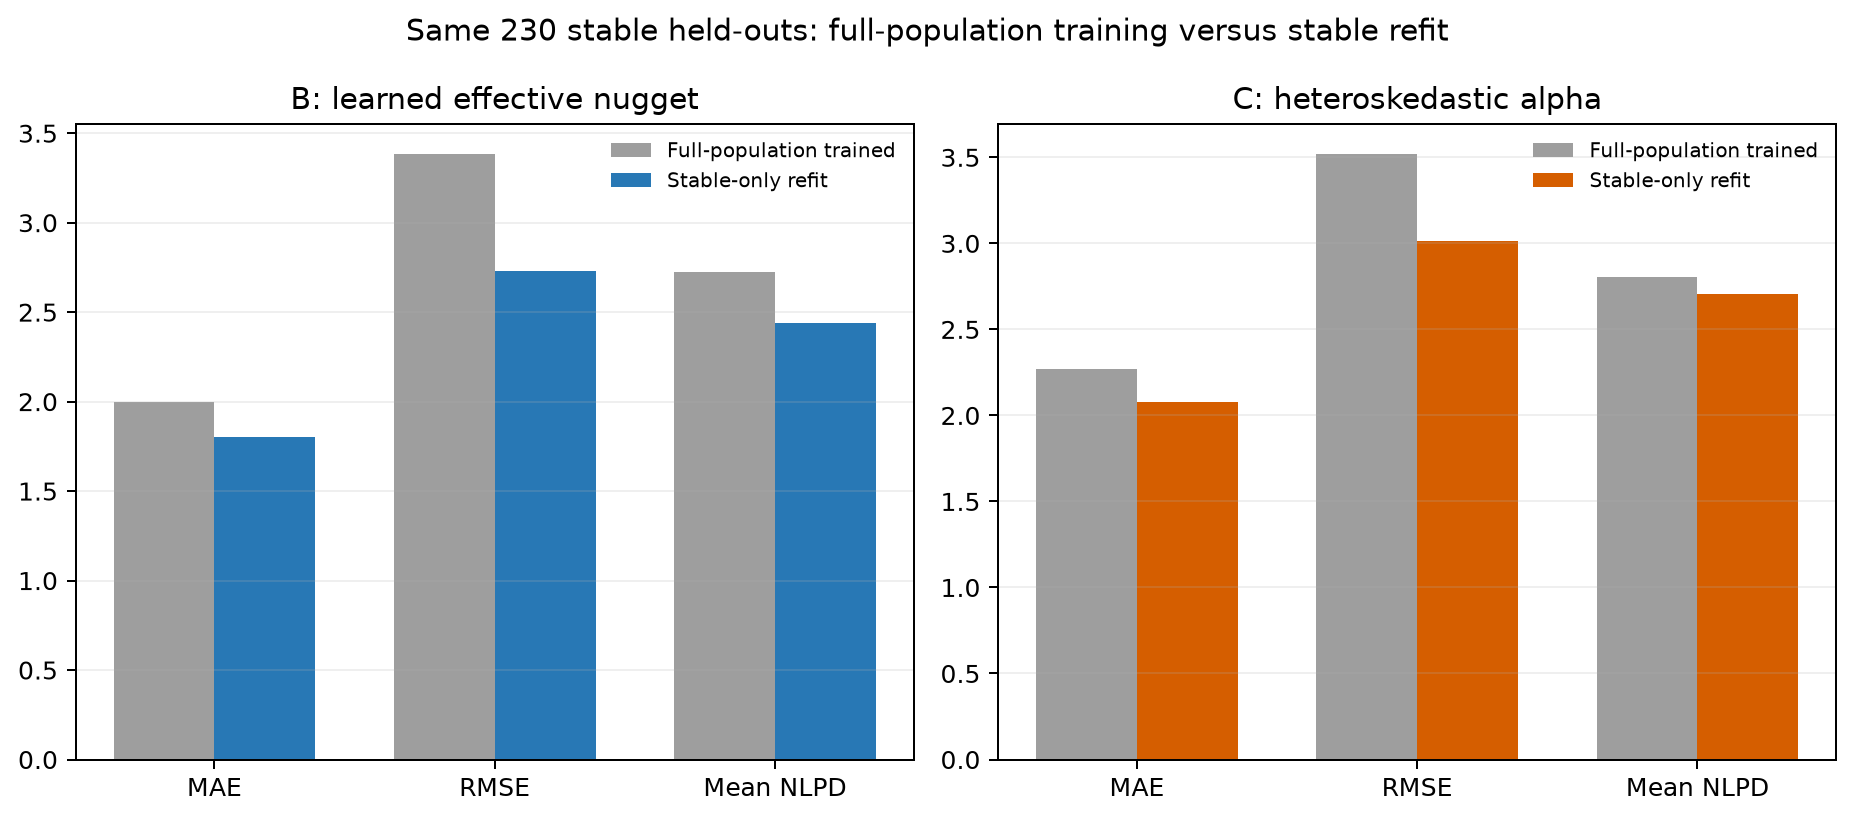

In [10]:
stable_vs_full = pd.read_csv(
    OUT / "stable_vs_full_population_comparison.csv"
)
display(
    stable_vs_full.loc[
        stable_vs_full["metric"].isin(
            ["mae_um", "rmse_um", "r2", "mean_nlpd"]
        ),
        [
            "method",
            "metric",
            "full_population_model_stable_heldouts",
            "stable_only_refit",
            "percent_change",
            "rmse_change_is_material",
        ],
    ].round(6)
)
display(
    Image(
        filename=str(OUT / "stable_depth_stable_vs_full_training.png")
    )
)

**For Burak.** This isolates the influence of unstable simulations in the training set.
The 5% RMSE threshold is only a descriptive materiality flag; it is not
a hypothesis test and does not declare any simulation invalid.

## 11. Inspect learned nugget and heteroskedastic alpha

The two observation treatments have different scientific meanings and
should not be compared as though they estimated the same quantity.

In [11]:
nugget = summary["method_summaries"]["learned_B_effective_nugget"]
alpha = summary["method_summaries"]["C_target_summary_uncertainty"]
pd.DataFrame(
    [
        {
            "quantity": "B effective-nugget std (µm)",
            "median": nugget["std_um_median"],
            "q95": nugget["std_um_q95"],
            "max": nugget["std_um_max"],
        },
        {
            "quantity": "C target-summary std (µm)",
            "median": alpha["std_um_median"],
            "q95": alpha["std_um_q95"],
            "max": alpha["std_um_max"],
        },
    ]
).round(6)

,quantity,median,q95,max
0,B effective-nugget std (µm),1.776750,1.786979,1.856438
1,C target-summary std (µm),0.007317,0.474441,1.149503


**For Burak.** WhiteKernel does not directly measure target-definition error: B's
nugget can also absorb omitted variables and fixed-kernel mismatch.
C's alpha comes only from temporal stability of each selected-window
median. Neither quantity is evidence of stochastic simulator noise.

## 12. Inspect optimizer warnings and bound hits

A bound hit means an optimized hyperparameter reached a configured
search boundary, which can signal weak identification or inadequate
bounds.

In [12]:
hyper = pd.read_csv(
    OUT / "stable_depth_hyperparameter_diagnostics.csv"
)
diagnostics = (
    hyper.groupby("method")
    .agg(
        folds=("fold_index", "size"),
        warning_folds=("warning_count", lambda s: (s > 0).sum()),
        failed_folds=("failed_fold", "sum"),
        constant_bound_hits=("constant_bound_hit", "sum"),
        lengthscale_bound_hits=("length_scale_bound_hit", "sum"),
        noise_bound_hits=("noise_bound_hit", "sum"),
        median_lengthscale=("optimized_length_scale", "median"),
        median_signal_variance=(
            "optimized_signal_variance_normalized",
            "median",
        ),
    )
    .reset_index()
)
diagnostics

,method,folds,warning_folds,failed_folds,constant_bound_hits,lengthscale_bound_hits,noise_bound_hits,median_lengthscale,median_signal_variance
0,B_learned_nugget,230,0,0,0,0,0,6.644820,5.997089
1,C_heteroskedastic,230,1,0,0,0,0,2.361424,1.239996


**For Burak.** Warnings and bound hits are diagnostics, not automatic invalidation.
Completed folds remain usable, but a method with repeated warnings or
boundary solutions deserves less trust.

## 13. Resolve the depth model decision

The decision follows the requested priority: paired point prediction,
calibration/NLPD, stable-training robustness, optimizer stability,
deployability/interpretation, then runtime.

In [13]:
decision = summary["decision"]
display(Markdown(f"### {decision['headline']}"))
pd.Series(
    {
        "paired superiority robust": decision[
            "paired_superiority_is_robust"
        ],
        "B has lower mean NLPD": decision["B_mean_nlpd_is_lower"],
        "B coverage closer to 95%": decision[
            "B_observation_coverage_is_closer_to_95_percent"
        ],
        "B total interval deployable": decision[
            "B_observation_interval_is_deployable_for_new_inputs"
        ],
        "C oracle interval deployable": decision[
            "C_oracle_interval_is_deployable_for_new_inputs"
        ],
    }
)

### B is preferred for stable-window penetration depth.

paired superiority robust        True
B has lower mean NLPD            True
B coverage closer to 95%         True
B total interval deployable      True
C oracle interval deployable    False
dtype: bool

**For Burak.** This is a target-specific operational decision under one fixed kernel,
not a universal GP winner. It does not authorize feature-effect claims
or Phase 3 work.

## 14. Explain the runtime metadata correction

The old 11.2-second field was traced to determine exactly what its timer
included and excluded.

In [14]:
runtime = json.loads(
    (OUT / "runtime_provenance.json").read_text(encoding="utf-8")
)
correction = runtime["phase2_runtime_metadata_correction"]
pd.Series(
    {
        "historical field": correction["original_field_name"],
        "historical seconds": correction["original_value_seconds"],
        "corrected name": correction[
            "corrected_authoritative_field_name"
        ],
        "classification": correction["classification"],
        "all checkpoints predated invocation": correction[
            "cache_evidence"
        ]["all_checkpoints_predate_timed_invocation"],
        "guessed durations reported": not runtime[
            "timing_principles"
        ]["no_inferred_duration_reported_as_measured"],
    }
)

historical field                                           full_pipeline_runtime_seconds
historical seconds                                                             11.208154
corrected name                         cached_artifact_assembly_figure_and_validation...
classification                         measured cached Phase 2 pre-report invocation,...
all checkpoints predated invocation                                                 True
guessed durations reported                                                         False
dtype: object

**For Burak.** The 11.2 seconds measured a cached pre-report invocation—artifact
loading/assembly, figures, and validation—not the original bootstrap
and GP fits. The historical value is preserved but its broad name is
deprecated. No file-timestamp estimate or summed parallel-fold time is
presented as a measured end-to-end runtime.

## 15. Validation checklist

Thirty automated checks cover provenance, subset identity, fold
alignment, scaling, leakage, variance mathematics, paired resampling,
source preservation, notebook execution, git hygiene, and runtime
provenance.

In [15]:
validation = pd.read_csv(OUT / "validation_results.csv")
non_notebook = validation.loc[validation["validation_number"] != 28]
assert non_notebook["status"].eq("PASS").all()
validation[["validation_number", "validation_check", "status", "details"]]

,validation_number,validation_check,status,details
0,1,exact Phase 1 provenance,PASS,revision=0e859b748fdbc8454f66e58e101e333ac0479d42
1,2,unchanged Phase 1 ledger hash,PASS,sha256=10DEF11AB64D62444AC14FED506266BEB748EEB...
2,3,exactly 230 stable simulations,PASS,"rows=230, unique=230"
3,4,exactly the expected 11 removed simulation IDs,PASS,"[""sim_00002"",""sim_00006"",""sim_00018"",""sim_0002..."
4,5,"features exactly P, VX, LS, ST",PASS,"[""P"",""VX"",""LS"",""ST""]"
5,6,target exactly penetration depth,PASS,melt_pool_depth_below_surface_selected_primary...
6,7,B and C use identical stable simulation IDs,PASS,aligned IDs=230
7,8,B and C use identical fold order,PASS,fold indices 0..229 and fold seeds are identical
8,9,exactly 230 B predictions,PASS,rows=230
9,10,exactly 230 C predictions,PASS,rows=230


**For Burak.** Before the notebook exists, check 28 is expected to be pending while
all other checks must pass. After execution and final validation, the
artifact becomes 30/30 PASS. Validation reduces implementation risk but
cannot prove the fixed scientific assumptions are true.

## 16. Final scientific conclusion

We finish with the exact supported conclusion and the limits that must
carry into later work.

In [16]:
display(Markdown((OUT / "depth_model_decision.md").read_text(encoding="utf-8")))

# Week 6 Phase 2.5 depth-model decision

## Why the closure was required

Phase 2 compared depth Methods B and C on all 241 simulations, but only C was
rerun after removing the 11 unstable-window simulations. Phase 2.5 closes that
single fairness gap. Width and length were not reopened because their learned-
nugget preference was already robust and the requested ambiguity concerns only
depth.

## Matched protocol

Both methods used the same 230 stable simulation IDs, ascending fold order, 229
training rows per exact LOO fold, training-only X/y scaling, the same Phase 2
fold seed, the same isotropic Matérn 3/2 kernel bounds, L-BFGS-B, and one
deterministic restart. Only the observation treatment differs.

- **B** learns one common WhiteKernel effective nugget per fold. It is a model-
  discrepancy term and not stochastic simulator noise.
- **C** uses existing simulation-specific moving-block-bootstrap variances of
  the selected-window median. They are target-summary uncertainty proxies and
  not measurement noise.

## Stable-only metrics

| Method | MAE µm | Median AE µm | RMSE µm | R² | nRMSE | Mean NLPD | Latent cov. | Total/oracle cov. |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| B | 1.802271 | 1.339809 | 2.728943 | 0.968873 | 0.036104 | 2.440425 | 0.8783 | 0.9522 |
| C | 2.076667 | 1.551698 | 3.013798 | 0.962036 | 0.039872 | 2.703817 | 0.9130 | 0.9130 |

B's NLPD/observation coverage use total variance including the learned nugget.
C's corresponding values use the held-out simulation's retrospective oracle
variance. The C oracle interval is not available for a genuinely unseen
simulation and is therefore not a deployable uncertainty interval.

## Paired result

- B improved `134` simulations; C improved
  `96`; ties `0`.
- `MAE_C − MAE_B = +0.274396 µm`,
  paired-bootstrap 95% CI
  `[+0.134941,
  +0.422091]`.
- `RMSE_C − RMSE_B = +0.284855 µm`,
  paired-bootstrap 95% CI
  `[+0.048306,
  +0.549011]`.

Negative differences favor C and positive differences favor B. A confidence
interval crossing zero does not support a robust superiority claim.

## Influence of unstable training simulations

- `B_learned_nugget`: full-population trained on the same stable held-outs `3.382290 µm`; stable-only refit `2.728943 µm`; change `-19.317%`; descriptive materiality `True`.
- `C_heteroskedastic`: full-population trained on the same stable held-outs `3.517802 µm`; stable-only refit `3.013798 µm`; change `-14.327%`; descriptive materiality `True`.

The 5% rule is a descriptive threshold, not a statistical test.

## Observation-treatment scale

- B median learned effective-nugget standard deviation:
  `1.776750 µm`; median fraction of fold training-target
  standard deviation:
  `0.114805`.
- C median stable target-summary bootstrap standard deviation:
  `0.007317 µm`; q95 `0.474441 µm`;
  maximum `1.149503 µm`.

These scales are not interchangeable: B can absorb unresolved variables and
fixed-kernel discrepancy, whereas C measures within-window median stability.

## Decision

**B is preferred for stable-window penetration depth.**

The paired point-prediction evidence is considered first. Calibration/NLPD,
training-set sensitivity, optimizer behavior, deployability, interpretation,
and runtime are secondary evidence. This decision does not prove causal input
effects and does not validate C's oracle interval for unseen simulations.


**For Burak.** Phase 2.5 resolves only the missing fair B-versus-C stable-depth
comparison. Width/length decisions remain historical Phase 2 results.
Phase 3 still has to be requested separately.